In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

sys.path.append(os.path.expanduser('~/git/desi-photoz/'))
from pz_modules import plot_photoz_specz

In [2]:
# params = {'legend.fontsize': 'large',
#           'axes.labelsize': 'large',
#           'axes.titlesize': 'large',
#           'xtick.labelsize': 'large',
#           'ytick.labelsize': 'large',
#           'figure.facecolor': 'w'}
# plt.rcParams.update(params)

In [3]:
# mask = tt['Z_PHOT_MEDIAN']!=-99
# print(np.sum(mask)/len(mask))

# plt.figure(figsize=(20, 20))
# plt.plot(cat['Z'][mask], cat['Z_PHOT_MEDIAN'][mask], '.', ms=0.1, alpha=0.1)
# plt.plot(np.arange(10), np.arange(10), lw=1, color='r')
# plt.axis([0, 1.8, 0, 1.8])
# plt.show()

__DR9 photo-z's__

FIBERSTATUS    0 2395952 0.0
No data    0 2395952 0.0
Min depth    0 2395952 0.0
Remove objects classified as STARs: 2395952 0 0.0
Redshift quality: 2355650 31989 0.013397754015577731
Valid photo-z's: 2355614 36 1.5282406129942902e-05
62
Bad fibers 2337529 18085 0.007677403853093079
2337529 2337529
Normalized MAD: 0.025405
0.10 outliers: 2.060723%


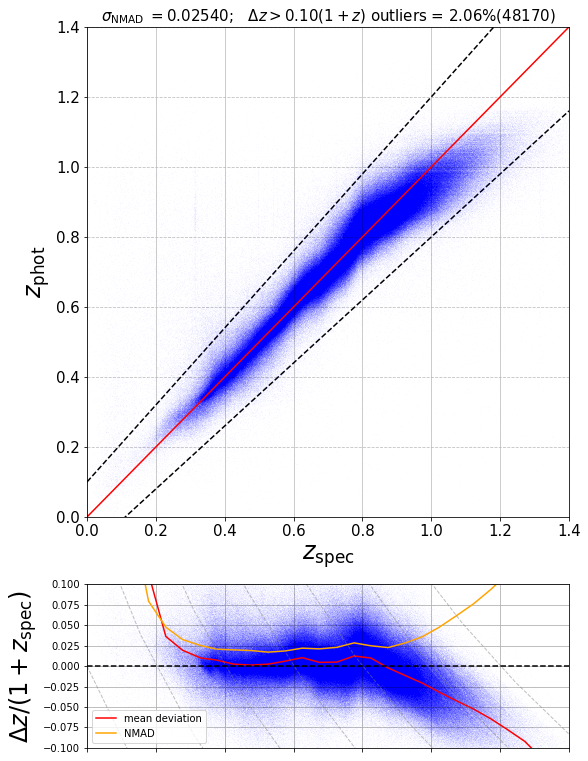

In [6]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_20221031.fits'))
tt = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_20221031-pz_dr9.fits'))
cat['Z_PHOT_MEDIAN'] = tt['Z_PHOT_MEDIAN']

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # # ZDONE fibers
# # mask = cat['ZDONE']==1
# # print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

# Remove objects classified as STARs
# Force the very low-z objects to have SPECTYPE=STAR
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[~mask_star]

mask_quality = cat['ZWARN']==0
mask_quality &= cat['DELTACHI2']>15
mask_quality &= cat['Z']<1.45
print('Redshift quality:', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]

mask = cat['Z_PHOT_MEDIAN']!=-99
print('Valid photo-z\'s:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_daily_20221101.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

plot_photoz_specz(cat['Z_PHOT_MEDIAN'], cat['Z'], zmax=1.4, markersize=0.05)

__New photo-z's__

FIBERSTATUS    0 2395952 0.0
No data    0 2395952 0.0
Min depth    0 2395952 0.0
Remove objects classified as STARs: 2395952 0 0.0
Redshift quality: 2355650 31989 0.013397754015577731
Valid photo-z's: 2355614 36 1.5282406129942902e-05
62
Bad fibers 2337529 18085 0.007677403853093079
2337529 2337529
Normalized MAD: 0.024793
0.10 outliers: 1.871763%


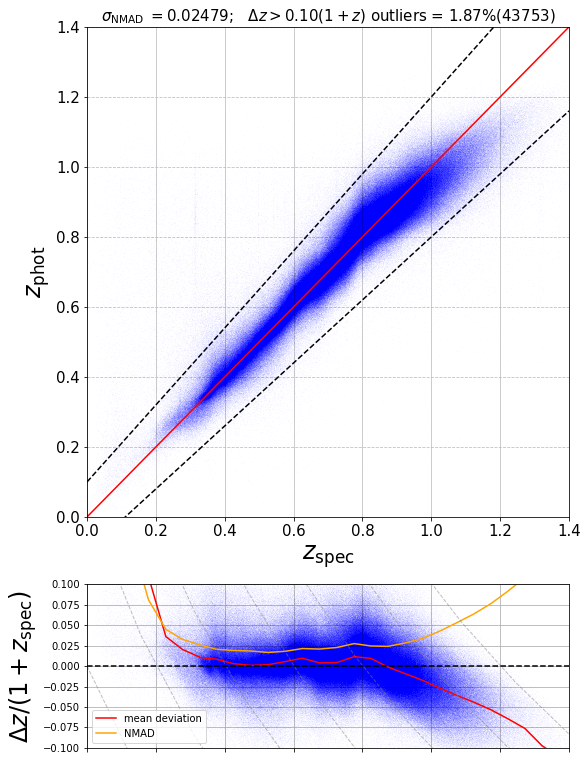

In [7]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_20221031.fits'))
tt = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/ls_dr9.0_photoz/misc/lss_daily_y1_lrg_full_20221031-pz_new.fits'))
cat['Z_PHOT_MEDIAN'] = tt['Z_PHOT_MEDIAN']

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # # ZDONE fibers
# # mask = cat['ZDONE']==1
# # print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

# Remove objects classified as STARs
# Force the very low-z objects to have SPECTYPE=STAR
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[~mask_star]

mask_quality = cat['ZWARN']==0
mask_quality &= cat['DELTACHI2']>15
mask_quality &= cat['Z']<1.45
print('Redshift quality:', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]

mask = cat['Z_PHOT_MEDIAN']!=-99
print('Valid photo-z\'s:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_daily_20221101.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

plot_photoz_specz(cat['Z_PHOT_MEDIAN'], cat['Z'], zmax=1.4, markersize=0.05)